# Part 1: An overview of Deep Learning

## Dataset

source: https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset

Ten baseline variables:
- age
- sex
- body mass index
- average blood pressure, and 
- six blood serum measurements, for each of 442 diabetes patients.

The response of interest: 
- A quantitative measure of disease progression one year after baseline.

In [127]:
# importing the scikit-learn library
from sklearn.datasets import load_diabetes
# importing numpy
import numpy as np

# loading diabetes dataset
diabetes = load_diabetes()
X = diabetes.data # extracting input features
Y = np.expand_dims(diabetes.target, axis=-1) # extracting targets
features = diabetes.feature_names # extracting feature names

In [128]:
# importing pandas library
import pandas as pd

# Loading the numpy arrays into a dataframe
df = pd.DataFrame(X, columns=features)

In [129]:
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019908,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068330,-0.092204
2,0.085299,0.050680,0.044451,-0.005671,-0.045599,-0.034194,-0.032356,-0.002592,0.002864,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022692,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031991,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018118,0.044485
439,0.041708,0.050680,-0.015906,0.017282,-0.037344,-0.013840,-0.024993,-0.011080,-0.046879,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044528,-0.025930


## Deep Learning

The word Deep Learning signifies that our Neural Network architecture is deep, i.e. there are multiple instances of each operation (specifically Matrix Multiplication and Bias Addition, as they make up a layer). These operations are applied in specific order such that they map input features to labels.

### Operations

**Matrix Multiplication**

Defining the `MatMul` function.

In [130]:
def matMul(inp_: np.ndarray, W: np.ndarray):
  '''
  Performs Matrix Multiplication
  '''
  return np.dot(inp_, W)

**Bias Addition**

Defining `biasAdd` function.

In [131]:
def biasAdd(B: np.ndarray, inp_: np.ndarray):
  '''
  Performs Bias Addition
  '''
  return inp_ + B

**Activation**

Defining *Sigmoid Activation* function and applying it to $Z_1$.

In [132]:
def sigmoid(Z):
  return 1/(1+np.exp(-Z))

Defining *Linear Activation*

In [133]:
def linear(Z):
    return Z

### Forward Pass

Completing the Neural Network by defining the remaining operations.

In [134]:
def init_weights(numX0, numH1, numH2):
    '''
    Initializing Parameters for the NN
		
		numX0: number of features in input dataset
		numH1: number of nodes in hidden layer
		numH2: number of nodes in output layer
    '''
    # defining weights and biases
    np.random.seed(0)
    W1 = np.random.rand(numX0,numH1)*0.01
    B1 = np.zeros((1, numH1))

    np.random.seed(1)
    W2 = np.random.rand(numH1, numH2)*0.01
    B2 = np.zeros((1, numH2))

    params = [W1, B1, W2, B2]
    return params

In [135]:
def forward(inp_: np.ndarray,
            params: list):
    '''
    Forward pass through a Neural Network
    '''
    W1, B1, W2, B2 = params

    # Forward Pass
    H1 = matMul(inp_, W1)
    Z1 = biasAdd(B1, H1)
    A1 = sigmoid(Z1)

    H2 = matMul(A1, W2)
    Z2 = biasAdd(B2, H2)
    A2 = linear(Z2)

    cache = (H1, Z1, A1, H2, Z2)
    return A2, cache

### Loss Function

**Mean Squared Error**

Defining the *Mean Squared Error* loss function.

In [136]:
def MSE(y, yHat):
    '''
    Mean Squared Error
    '''
    n = y.shape[0]
    return 1/n*np.sum(np.square(y-yHat), axis=0)

# Part 2: Training a Neural Network

Let's now define all the gradients required.

## Grads

In [137]:
def gradMSE(y, yHat):
    '''
    Function that computes gradient
    of loss wrt yHat
    '''
    n = y.shape[0]
    return -2/n*(y-yHat)

In [138]:
def grad_linear(outGrad, inp_):
    '''
    Function that computes gradient
    of loss wrt inp_
		
		outGrad: Gradient of Loss wrt Yhat
		inp_: Input to Linear Activation i.e. Z2
    '''
		# Grad of Yhat wrt to Z2 is a matrix of ones
    dinp_ = outGrad * np.ones(inp_.shape) 
    return dinp_

In [139]:
def grad_biasAdd(outGrad, B, inp_):
    '''
    Function that computes gradient
    of loss wrt B and H
    '''
    dB = np.sum(outGrad, axis=0)
    dinp_ = outGrad * np.ones(inp_.shape)
    return np.expand_dims(dB, axis=0), dinp_

In [140]:
def grad_matMul(outGrad, W, inp_):
    '''
    Function that computes gradient
    of loss wrt W and inp_
    '''
    dW = np.dot(inp_.T, outGrad)
    dinp_ = np.dot(outGrad, W.T)
    return dW, dinp_

In [141]:
def grad_sigmoid(outGrad, inp_):
    '''
    Function that computes gradient
    of loss wrt inp_
    '''
    dinp_ = outGrad * sigmoid(inp_)*(1-sigmoid(inp_)) 
    return dinp_

## Backward Pass

In [142]:
def backward(x, y, yHat, params, cache):
    '''
    Does Backward pass through the Network 
    to compute all the gradients required
    '''
    H1, Z1, A1, H2, Z2 = cache
    W1, B1, W2, B2 = params

    dYhat = gradMSE(y, yHat)
    
    dZ2 = grad_linear(dYhat, Z2)

    dB2, dH2 = grad_biasAdd(dZ2, B2, H2)
    assert B2.shape == dB2.shape

    dW2, dA1 = grad_matMul(dH2, W2, A1)
    assert W2.shape == dW2.shape

    dZ1 = grad_sigmoid(dA1, Z1)

    dB1, dH1 = grad_biasAdd(dZ1, B1, H1)
    assert B1.shape == dB1.shape

    dW1, _ = grad_matMul(dH1, W1, x)
    assert W1.shape == dW1.shape

    param_grads = (dW1, dB1, dW2, dB2)
    return param_grads

## Gradient Descent: Updating the weights

In [143]:
def update(params, param_grads, alpha):
    '''
    Updating the Parameters using SGD
    '''
    assert len(params) == len(param_grads)

    for i in range(len(params)):
        params[i] -= alpha*param_grads[i]

    return params

# Part 3: Predicting the "Disease Progression"

## Training NN

Putting everything together in one training function.

In [178]:
def train(X, Y, epochs, alpha):
    '''
    A function that performs:
    1) Forward pass
    2) Calculates loss
    3) Backward pass
    4) Update Weights

    X: Training Input data
    Y: Training Labels
    epochs: Number of epochs
    '''

    # list to store loss after each epoch
    lossVals = []

    # initialising parameters
    params = init_weights(X.shape[1], 12, Y.shape[1])

    for i in range(epochs):
        # forward pass
        yHat, cache = forward(X, params)

        # loss
        lossVal = MSE(Y, yHat)

        # backward pass
        param_grads = backward(X, Y, yHat, params, cache)

        # updating weights
        params = update(params, param_grads, alpha)

        # storing the loss value
        lossVals.append(lossVal)

        # printing the loss value
        if i%1000 == 0:
            print("Loss after {} epochs: {}".format(i, lossVal))

    return params, lossVals

**Train-Test Split**

In [183]:
# importing scikit-learn's train test split module
from sklearn.model_selection import train_test_split

# splitting training and testing dataset
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.1)

**Training**

In [184]:
params, lossVals = train(X_train, y_train, 10000, 0.01)

Loss after 0 epochs: [29428.36957861]
Loss after 1000 epochs: [2870.05984198]
Loss after 2000 epochs: [2774.89236913]
Loss after 3000 epochs: [2743.26335023]
Loss after 4000 epochs: [2715.18412103]
Loss after 5000 epochs: [2681.60234794]
Loss after 6000 epochs: [2625.41179106]
Loss after 7000 epochs: [2560.96666223]
Loss after 8000 epochs: [2498.55382327]
Loss after 9000 epochs: [2443.60359718]


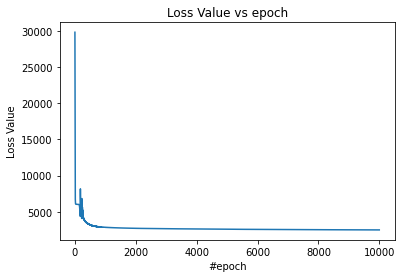

In [147]:
import matplotlib.pyplot as plt

plt.title("Loss Value vs epoch")
plt.plot(lossVals)
plt.xlabel("#epoch")
plt.ylabel("Loss Value")
plt.show()

## Testing NN

In [148]:
def test(X, Y, params):
    '''
    A function that performs:
    1) Forward pass
    2) Calculates loss

    X: Training Input data
    Y: Training Labels
    params: Parameters of trained NN
    '''

    # forward pass
    yHat, _ = forward(X, params)

    # loss
    lossVal = MSE(Y, yHat)

    print("Mean Squared Error on test-set: ", lossVal)

    return lossVal

In [149]:
testLossVal = test(X_test, y_test, params)

Mean Squared Error on test-set:  [2453.26090712]
